In [49]:
import numpy as np
import json
import csv
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import matplotlib.font_manager as font_manager
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

### Plot where an individual article was shared (Fig. 3, two top panels)

In [50]:
party_positions = pd.read_csv('./data/party_pos_FINAL.csv')

In [51]:
edgelist = pd.read_csv('./data/shares_pseudo.csv', dtype = str)
edgelist = edgelist.drop_duplicates(subset = ['tweet_id'])

In [52]:
user_embedding = './data/embedding_pseudo.csv'

user_emb_df = pd.read_csv(user_embedding, dtype = str)
user_emb_df = user_emb_df.set_index('user')

In [53]:
user_list = list(edgelist.user)
pos_dict = user_emb_df.T.to_dict('list')

/var/folders/_p/7vwplj9155x7q1tghmrxfnlr0000gp/T/ipykernel_12875/527989846.py:2: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  pos_dict = user_emb_df.T.to_dict('list')


In [54]:
art_to_id_df = pd.read_csv('./data/articles_to_id.csv', dtype = str)

In [55]:
link_to_article_id = dict(zip(art_to_id_df['link'], art_to_id_df['article_id']))
# Map the 'url' column in edgelist to 'article_id'
edgelist['article_id'] = edgelist['url'].map(link_to_article_id)

In [56]:
pos_list_x = []
pos_list_y = []

ct = 0
ne_ct=0

for user_id in tqdm(user_list):
    if user_id in pos_dict.keys():
        pos_list_x.append(pos_dict[user_id][0])
        pos_list_y.append(pos_dict[user_id][1])
        ct +=1
    else:
        pos_list_x.append('not_embedded')
        pos_list_y.append('not_embedded')
        ne_ct +=1

edgelist['x'] = pos_list_x
edgelist['y'] = pos_list_y

100%|██████████████████████████████| 542764/542764 [00:00<00:00, 1247871.65it/s]


In [57]:
def plot_article(link, edgelist, party_positions, link_to_article_id, title, story_color, story_alpha, hist_alpha):

    STORY_COLOR = story_color
    STORY_ALPHA = story_alpha
    STORY_COLOR_MEAN = "red"

    if link in link_to_article_id:
        article_id = link_to_article_id[link]
        print(f"Link found. Using article_id = {article_id} for filtering.")
        # Use article_id to filter edgelist
        frame = edgelist[edgelist['article_id'] == article_id]
    else:
        article_id = None
        print(f"Link not found in art_to_id_df. Using link directly for filtering.")
        # Fallback: use link to filter
        frame = edgelist[edgelist['url'] == link]


    # Step 3: Extract x and y coordinates (excluding 'not_embedded')
    x = [i for i in list(frame['x']) if i != 'not_embedded']
    y = [i for i in list(frame['y']) if i != 'not_embedded']

    # Convert to float
    x = [float(s) for s in x]
    y = [float(s) for s in y]

    # Compute mean
    mean_x = sum(x) / len(x) if x else 0
    mean_y = sum(y) / len(y) if y else 0

    # Ensure pol_df columns are float
    party_positions['0'] = party_positions['0'].astype(float)
    party_positions['2'] = party_positions['2'].astype(float)

    # Extract party positions
    x_mp = list(party_positions['0'])
    y_mp = list(party_positions['2'])

    # Plot setup

    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(2, 2, width_ratios=(7, 1), height_ratios=(1, 7),
                          left=0.1, right=0.9, bottom=0.1, top=0.9,
                          wspace=0.005, hspace=0.005)

    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

    # Article shares
    story = ax.scatter(x, y, c=STORY_COLOR, marker='x', alpha=STORY_ALPHA)
    smean = ax.scatter(mean_x, mean_y, c=STORY_COLOR_MEAN, marker='x', s=150)

    # Party positions
    color_list = list(party_positions['color'])
    party_positions.plot(kind='scatter',
                x='0',
                y='2',
                c=color_list,
                s=130,
                alpha=0.5,
                marker='o',
                ax=ax,
                edgecolors='black'
                )

    # Title and labels
    ax.set_title(title,
                 fontsize=20,
                 loc='left',
                 fontdict={'weight': 'bold'},
                 x=0.02, y=0.88)

    ax.set_xlabel('Left-right', fontsize=17)
    ax.set_ylabel('Elite-/EU-skeptical/Protectionist', fontsize=17)

    # Axis limits
    ax.set_ylim(-2, 4)
    ax.set_xlim(-3, 3)

    # Legend
    patch = Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='w', markeredgecolor='black', markersize=7)

    legend = ax.legend([story, smean, patch],
                       ('Individual shares', 'Mean', 'Party position'),
                       loc=(0.03, 0.05))

    # Ensure legend marker sizes are consistent
    for marker_idx in range(3):
        legend.legend_handles[marker_idx]._sizes = [50]

    # Histograms
    binwidth = 0.05
    xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
    lim = (int(xymax / binwidth) + 1) * binwidth
    bins = np.arange(-lim, lim + binwidth, binwidth)

    ax_histx.hist(x, bins=bins, density=False, color=STORY_COLOR, alpha=hist_alpha)
    ax_histy.hist(y, bins=bins, orientation='horizontal', color=STORY_COLOR, alpha=hist_alpha)

    # Styling
    ax_histx.axis('off')
    ax_histy.axis('off')
    ax.grid(alpha=0.3)
    ax.tick_params(direction='in', which='both', width=1, top=True, right=True)
    ax.tick_params(direction='in', which='major', width=1, length=10)
    ax.tick_params(direction='in', which='minor', width=1, length=5)

    # Color tick labels (optional)
    for i in range(7):
        if i != 3:
            ax.get_xticklabels()[i].set_color("white")
    for i in range(7):
        if i != 2:
            ax.get_yticklabels()[i].set_color("white")

    # Save and close
    plt.savefig(f'./{title}.pdf', dpi=300)
    plt.show()
    plt.close()

    return None

/var/folders/_p/7vwplj9155x7q1tghmrxfnlr0000gp/T/ipykernel_12875/1705393465.py:91: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  legend.legendHandles[marker_idx]._sizes = [50]


Link found. Using article_id = 2577 for filtering.


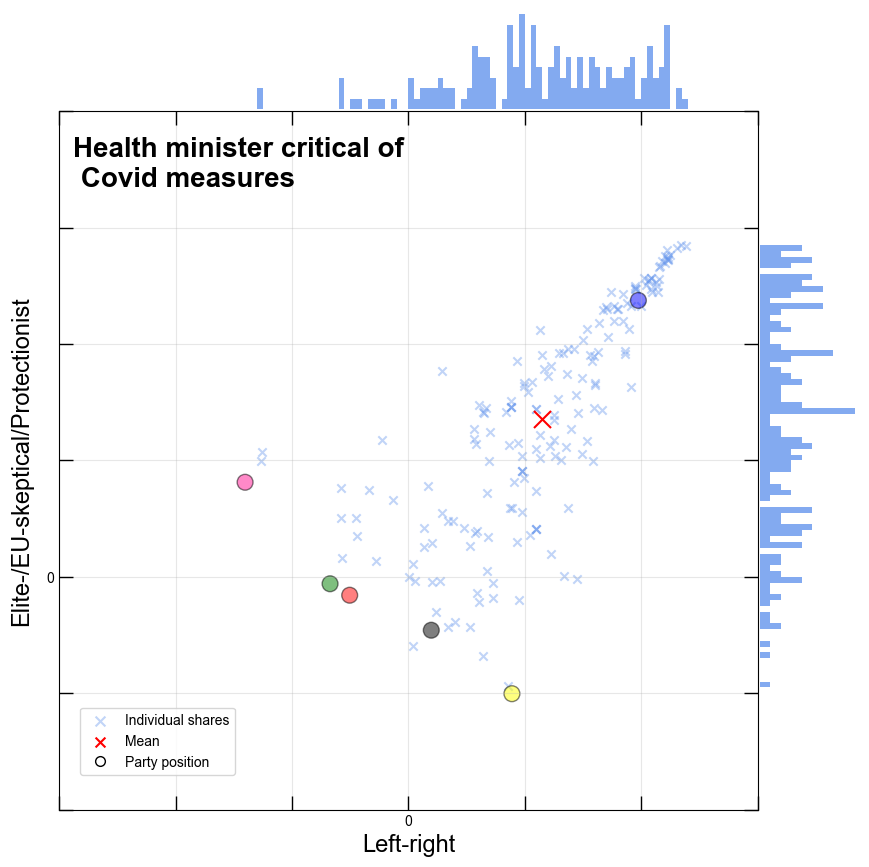

In [58]:
test_link = 'https://faz.net/aktuell/politik/inland/corona-bilanz-manche-massnahmen-waren-laut-karl-lauterbach-schwachsinn-18667895.html'
plot_article(test_link, edgelist, party_positions, link_to_article_id, 
             'Health minister critical of \n Covid measures', story_color='#6495ED',story_alpha=.4, hist_alpha=.8)